# Análise Descritiva e Pré-processamento — Tabela 1407 (IBGE/SIDRA)
### Classificação do Desempenho das Empresas Comerciais Brasileiras nos Cenários de Pré-Pandemia, Pandemia e Retomada (2017–2023)

**Etapas do roteiro cobertas:** Passo 1 (escolha e descrição da base), Passo 2 (extração e análise de conhecimento) e Passo 3 até os itens *dados ausentes* e *ruídos e outliers*.

**Base de dados:** Tabela 1407 — Dados gerais das empresas comerciais por grandes regiões e unidades da federação de atuação das empresas e divisão de comércio e grupo de atividade (Pesquisa Anual de Comércio — IBGE/SIDRA).
Repositório: https://sidra.ibge.gov.br/Tabela/1407

Este notebook:
1. Descreve a base escolhida (Passo 1, logo abaixo);
2. Carrega e reestrutura (melt) as 5 planilhas da base bruta em uma tabela "tidy" (seção 1);
3. Restringe o escopo geográfico às regiões Sudeste, Sul e Centro-Oeste (seção 1.1);
4. Faz uma verificação de qualidade dos dados (seção 2);
5. Produz as análises descritivas exigidas pelo roteiro — distribuições, boxplots por período, correlações, dispersão, evolução temporal (seções 3 a 9);
6. Trata **dados ausentes** (seção 10) e avalia **ruídos** (seção 11) e **outliers** (seção 12);
7. Consolida os insights e os próximos passos (seção 13).


## Passo 1 — Escolha e descrição da base de dados

| Item do roteiro | Descrição |
|---|---|
| **Base escolhida** | Tabela 1407 — Dados gerais das empresas comerciais por grandes regiões e unidades da federação de atuação das empresas e divisão de comércio e grupo de atividade. Base real, pública e oficial. |
| **Origem** | IBGE — Pesquisa Anual de Comércio (PAC), obtida no SIDRA: https://sidra.ibge.gov.br/Tabela/1407 |
| **Contexto** | A PAC acompanha anualmente a estrutura e o desempenho das empresas comerciais do país. A série 2017–2023 permite comparar três cenários: **pré-pandemia** (2017–2019), **pandemia** (2020–2022) e **retomada** (2023). Os valores monetários estão em R$ mil correntes, ou seja, nominais e sem deflacionar. |
| **Formato** | Arquivo Excel (`tabela1407.xlsx`, cerca de 200 KB) com 6 abas: 5 de dados (uma por variável) e a aba *Notas* (legenda dos símbolos do IBGE). Em cada aba de dados, as linhas são as 23 categorias de atividade e as colunas cruzam 7 anos × 33 geografias (formato "largo"). |
| **Tamanho da base bruta** | Após a reestruturação (seção 1), antes de qualquer recorte: **5.313 registros × 11 colunas** = 23 categorias × 33 geografias (Brasil, 5 regiões, 27 UFs) × 7 anos. |
| **Recorte usado na análise** | Por decisão do projeto (seção 1.1), a análise exclui as regiões **Norte e Nordeste** (16 UFs). A base analisada tem **2.415 registros brutos** (15 geografias: Brasil, 3 regiões e 11 UFs), dos quais **1.134 trazem dados de fato** (ver seção 10). |
| **Objetivo** | **Classificação supervisionada:** classificar o desempenho das empresas comerciais em classes (queda / estável / crescimento) em cada cenário. A variável-alvo será derivada das variações percentuais dos indicadores (pessoal ocupado e/ou unidades locais — ver seção 4) e ainda não existe na base. |
| **Unidade de análise** | Um registro = uma combinação de categoria de atividade × geografia × ano. |

**Instâncias:** 5.313 registros na base bruta; 2.415 após o recorte geográfico (seção 1.1); 1.134 com dados de fato (após a seção 10).
**Atributos:** 11 colunas — 6 numéricas (o ano e 5 indicadores) e 5 categóricas.

| Atributo | Tipo | Descrição / unidade |
|---|---|---|
| `categoria` | categórico nominal (23 níveis, hierárquico) | Divisão de comércio e grupo de atividade: 1. Total; 2. Veículos; 3. Atacado (3.1 a 3.8, com 3.5.1 e 3.5.2); 4. Varejo (4.1 a 4.7, com 4.1.1 e 4.1.2) |
| `geografia` | categórico nominal (33 níveis; 15 após o recorte da seção 1.1) | Brasil, 5 grandes regiões e 27 unidades da federação |
| `ano` | numérico discreto (temporal) | 2017 a 2023 |
| `unidades_locais` | numérico discreto | Nº de unidades locais com receita de revenda (unidades) |
| `pessoal_ocupado` | numérico discreto | Pessoal ocupado em 31/12 (pessoas) |
| `gastos_salarios` | numérico contínuo | Salários, retiradas e outras remunerações (R$ mil) |
| `margem_comercializacao` | numérico contínuo | Receita líquida de revenda menos o custo da mercadoria vendida (R$ mil) |
| `receita_bruta` | numérico contínuo | Receita bruta de revenda de mercadorias (R$ mil) |
| `periodo` | categórico ordinal (derivado) | Pré-pandemia < Pandemia < Retomada |
| `nivel_geografico` | categórico nominal (derivado) | Brasil / Região / UF |
| `macrorregiao` | categórico nominal (derivado) | Grande região a que a geografia pertence |


In [1]:
%pip install -q pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# Caminho do arquivo bruto baixado do SIDRA (ajuste se necessário)
DATA_PATH = "tabela1407.xlsx"


## 1. Carregamento e reestruturação dos dados

A planilha original vem no formato "largo" do SIDRA: cada uma das 5 abas de dados é uma variável, com as categorias de atividade nas linhas e o cruzamento **ano × geografia** nas colunas. Antes de qualquer análise, é preciso transformar isso em uma tabela "tidy" — uma linha por combinação (categoria, geografia, ano), com as 5 variáveis como colunas.

In [3]:
REGIAO_POR_UF = {
    'Rondônia': 'Região Norte', 'Acre': 'Região Norte', 'Amazonas': 'Região Norte',
    'Roraima': 'Região Norte', 'Pará': 'Região Norte', 'Amapá': 'Região Norte',
    'Tocantins': 'Região Norte',
    'Maranhão': 'Região Nordeste', 'Piauí': 'Região Nordeste', 'Ceará': 'Região Nordeste',
    'Rio Grande do Norte': 'Região Nordeste', 'Paraíba': 'Região Nordeste',
    'Pernambuco': 'Região Nordeste', 'Alagoas': 'Região Nordeste', 'Sergipe': 'Região Nordeste',
    'Bahia': 'Região Nordeste',
    'Minas Gerais': 'Região Sudeste', 'Espírito Santo': 'Região Sudeste',
    'Rio de Janeiro': 'Região Sudeste', 'São Paulo': 'Região Sudeste',
    'Paraná': 'Região Sul', 'Santa Catarina': 'Região Sul', 'Rio Grande do Sul': 'Região Sul',
    'Mato Grosso do Sul': 'Região Centro-Oeste', 'Mato Grosso': 'Região Centro-Oeste',
    'Goiás': 'Região Centro-Oeste', 'Distrito Federal': 'Região Centro-Oeste',
}

NOMES_CURTOS = {
    'Número de unidades locais com receita de revenda': 'unidades_locais',
    'Pessoal ocupado em 31/12 em empresas comerciais': 'pessoal_ocupado',
    'Gastos com salários, retiradas e outras remunerações em empresas comerciais': 'gastos_salarios',
    'Margem de comercialização em empresas comerciais': 'margem_comercializacao',
    'Receita bruta de revenda de mercadorias': 'receita_bruta',
}

def periodo_do_ano(ano):
    if ano <= 2019:
        return 'Pré-pandemia'
    elif ano <= 2022:
        return 'Pandemia'
    return 'Retomada'

def limpar_valor(v):
    # Converte os símbolos do IBGE/SIDRA (ver aba 'Notas') em valores numéricos ou NaN.
    if isinstance(v, str):
        v = v.strip()
        if v == '-':
            return 0.0          # zero absoluto (estrutural, não é dado faltante)
        if v in ('X', '..', '...'):
            return np.nan        # sigiloso / não se aplica / não disponível -> tratar como ausente
        v = v.replace('.', '').replace(',', '.')
        try:
            return float(v)
        except ValueError:
            return np.nan
    return v


In [4]:
def parse_sheet(path, sheet_name):
    # Transforma uma aba (uma variável) do arquivo bruto do SIDRA em formato longo.
    df = pd.read_excel(path, sheet_name=sheet_name, header=None)
    variavel = str(df.iloc[1, 0]).replace('Variável - ', '').strip()

    row_ano, row_geo = df.iloc[3], df.iloc[4]
    anos_cols = [c for c in range(4, df.shape[1]) if pd.notna(row_ano[c])]

    col0 = df[0].astype(str)
    fim_idx = col0[col0.str.contains('Fonte', na=False)].index
    fim = fim_idx[0] if len(fim_idx) else len(df)
    categorias = df.iloc[5:fim, 3].tolist()

    registros = []
    for ano_col in anos_cols:
        ano = int(row_ano[ano_col])
        # dentro de cada bloco de ano, as geografias vêm a cada 2 colunas (valor, unidade)
        geo_cols = [c for c in range(ano_col, ano_col + 66, 2) if pd.notna(row_geo[c])]
        for geo_col in geo_cols:
            geografia = row_geo[geo_col]
            for i, categoria in enumerate(categorias):
                valor = limpar_valor(df.iloc[5 + i, geo_col])
                registros.append((variavel, categoria, geografia, ano, valor))
    return pd.DataFrame(registros, columns=['variavel', 'categoria', 'geografia', 'ano', 'valor'])


def carregar_base(path):
    xls = pd.ExcelFile(path)
    sheets = [s for s in xls.sheet_names if s != 'Notas']
    long_df = pd.concat([parse_sheet(path, s) for s in sheets], ignore_index=True)

    wide = long_df.pivot_table(
        index=['categoria', 'geografia', 'ano'], columns='variavel',
        values='valor', aggfunc='first'
    ).reset_index()
    wide.columns.name = None
    wide = wide.rename(columns=NOMES_CURTOS)

    wide['periodo'] = pd.Categorical(
        wide['ano'].apply(periodo_do_ano),
        categories=['Pré-pandemia', 'Pandemia', 'Retomada'], ordered=True
    )
    wide['nivel_geografico'] = wide['geografia'].apply(
        lambda g: 'Brasil' if g == 'Brasil' else ('Região' if g.startswith('Região') else 'UF')
    )
    wide['macrorregiao'] = wide['geografia'].map(REGIAO_POR_UF)
    wide.loc[wide['nivel_geografico'] == 'Região', 'macrorregiao'] = wide.loc[wide['nivel_geografico'] == 'Região', 'geografia']
    wide.loc[wide['nivel_geografico'] == 'Brasil', 'macrorregiao'] = 'Brasil'
    return wide


df = carregar_base(DATA_PATH)
print(f"Base reestruturada: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Base reestruturada: 5313 linhas x 11 colunas


,categoria,geografia,ano,gastos_salarios,margem_comercializacao,unidades_locais,pessoal_ocupado,receita_bruta,periodo,nivel_geografico,macrorregiao
0,1. Total,Acre,2017,378703.0,1504909.0,2253.0,18677.0,6100495.0,Pré-pandemia,UF,Região Norte
1,1. Total,Acre,2018,405822.0,1559364.0,2236.0,18621.0,6856758.0,Pré-pandemia,UF,Região Norte
2,1. Total,Acre,2019,389075.0,1594276.0,2098.0,18034.0,7014019.0,Pré-pandemia,UF,Região Norte
3,1. Total,Acre,2020,433694.0,1871693.0,2257.0,19827.0,7915438.0,Pandemia,UF,Região Norte
4,1. Total,Acre,2021,468303.0,2259361.0,2359.0,19321.0,9327029.0,Pandemia,UF,Região Norte


## 1.1 Recorte geográfico: exclusão de Norte e Nordeste

**Decisão do projeto:** as regiões **Norte e Nordeste** (16 UFs) serão excluídas do restante da análise. A partir daqui, `df` contém apenas Brasil, as regiões Sudeste, Sul e Centro-Oeste, e as 11 UFs dessas três regiões.

**Ressalva importante (ver seção 10 para os números completos):** o detalhamento por subgrupo de atividade (categorias 3.x e 4.x) só existe em 6 UFs — Minas Gerais, Paraná, Rio de Janeiro, Rio Grande do Sul, Santa Catarina e São Paulo — e essa limitação **não é exclusiva do Norte/Nordeste**: das 21 UFs sem esse detalhamento, 5 (Espírito Santo e as 4 UFs do Centro-Oeste) permanecem na base mesmo depois deste recorte. Ou seja, excluir Norte e Nordeste reduz o volume de dados ausentes tratados como estruturais (seção 10), mas não elimina completamente essa limitação — ela só é resolvida de fato ao restringir a análise por subgrupo às 6 UFs citadas (o que a seção 8 já fazia).


In [5]:
REGIOES_EXCLUIDAS = ['Região Norte', 'Região Nordeste']
UFS_EXCLUIDAS = sorted(uf for uf, reg in REGIAO_POR_UF.items() if reg in REGIOES_EXCLUIDAS)

antes = len(df)
df = df[~df['geografia'].isin(REGIOES_EXCLUIDAS + UFS_EXCLUIDAS)].reset_index(drop=True)

print(f"UFs excluídas ({len(UFS_EXCLUIDAS)}): {UFS_EXCLUIDAS}")
print(f"Registros: {antes} -> {len(df)} (removidos {antes - len(df)})")
print("\nGeografias mantidas:", sorted(df['geografia'].unique()))
print("\nUFs mantidas por macrorregião:")
print(df[df['nivel_geografico'] == 'UF'].groupby('macrorregiao')['geografia'].nunique().to_string())


UFs excluídas (16): ['Acre', 'Alagoas', 'Amapá', 'Amazonas', 'Bahia', 'Ceará', 'Maranhão', 'Paraíba', 'Pará', 'Pernambuco', 'Piauí', 'Rio Grande do Norte', 'Rondônia', 'Roraima', 'Sergipe', 'Tocantins']
Registros: 5313 -> 2415 (removidos 2898)

Geografias mantidas: ['Brasil', 'Distrito Federal', 'Espírito Santo', 'Goiás', 'Mato Grosso', 'Mato Grosso do Sul', 'Minas Gerais', 'Paraná', 'Região Centro-Oeste', 'Região Sudeste', 'Região Sul', 'Rio Grande do Sul', 'Rio de Janeiro', 'Santa Catarina', 'São Paulo']

UFs mantidas por macrorregião:
macrorregiao
Região Centro-Oeste    4
Região Sudeste         4
Região Sul             3


## 2. Panorama geral e verificação de qualidade dos dados

Antes de plotar qualquer gráfico, é essencial entender a cobertura real da base: quantas categorias, geografias e anos existem, e se há alguma limitação estrutural nos dados.

In [6]:
print("Categorias (grupos de atividade):", df['categoria'].nunique())
print("Geografias:", df['geografia'].nunique(), "| Anos:", sorted(df['ano'].unique()))
print()
print(df['nivel_geografico'].value_counts())
print()
df[['unidades_locais', 'pessoal_ocupado', 'gastos_salarios', 'margem_comercializacao', 'receita_bruta']].describe().round(1)


Categorias (grupos de atividade): 23
Geografias: 15 | Anos: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

nivel_geografico
UF        1771
Região     483
Brasil     161
Name: count, dtype: int64



,unidades_locais,pessoal_ocupado,gastos_salarios,margem_comercializacao,receita_bruta
count,2415.0,2415.0,2415.0,2.415000e+03,2.415000e+03
mean,19118.2,123339.1,3425318.5,1.334880e+07,6.682608e+07
std,104795.1,664451.9,18480180.2,7.292564e+07,3.605028e+08
min,0.0,0.0,0.0,0.000000e+00,0.000000e+00
25%,0.0,0.0,0.0,0.000000e+00,0.000000e+00
50%,0.0,0.0,0.0,0.000000e+00,0.000000e+00
75%,4675.0,36467.5,1134311.5,5.371928e+06,3.247420e+07
max,1702147.0,10545204.0,352656650.0,1.551682e+09,7.697487e+09


**Achado importante de qualidade dos dados:** ao verificar os valores `-` (zero absoluto, conforme a aba *Notas* do arquivo original), percebe-se que a base tem uma cobertura bem mais restrita do que o formato sugere:

- **Brasil e as 3 grandes regiões mantidas (Sudeste, Sul, Centro-Oeste):** só a categoria **"1. Total"** tem dados; todos os grupos e subgrupos aparecem como zero.
- **As 11 UFs mantidas:** todas têm dados para **"1. Total"** e para os **3 grandes grupos** (2. veículos, 3. atacado, 4. varejo).
- **Subgrupos 3.x e 4.x (19 categorias):** só **6 das 11 UFs** (MG, PR, RJ, RS, SC e SP) têm dados; nas outras 5 UFs mantidas (ES, DF, GO, MS, MT) todos aparecem como zero.

Esses zeros não são zeros reais (a seção 10 detalha a evidência). Duas consequências: (i) as estatísticas do `describe()` acima (mediana e quartis iguais a 0) refletem os zeros estruturais e não a distribuição real; (ii) **decisão de análise:** comparações por grupo de atividade (veículos / atacado / varejo) usam o nível UF e os 3 grandes grupos, e Brasil e regiões só são usados para a categoria **"1. Total"**.


In [7]:
agregados = df[df['nivel_geografico'].isin(['Brasil', 'Região'])]
pct_zero_por_categoria = (
    agregados[agregados['categoria'] != '1. Total']
    .groupby('categoria')['receita_bruta']
    .apply(lambda s: (s == 0).mean())
)
print("% de zeros estruturais por categoria em Brasil/Região (deveria ser ~100%):")
print(pct_zero_por_categoria.round(2).to_string())


% de zeros estruturais por categoria em Brasil/Região (deveria ser ~100%):
categoria
2. Comércio de veículos, peças e motocicletas                                                            1.0
3. Comércio por atacado                                                                                  1.0
3.1 Representantes e agentes do comércio (exceto de veículos e motocicletas)                             1.0
3.2 Comércio de matérias-primas agrícolas e animais vivos                                                1.0
3.3 Produtos alimentícios, bebidas e fumo                                                                1.0
3.4 Comércio de equipamentos e artigos de uso pessoal e doméstico                                        1.0
3.5 Comércio de produtos intermediários, resíduos e sucatas                                              1.0
3.5.1 Combustíveis e lubrificantes                                                                       1.0
3.5.2 Outros produtos intermediários       

In [8]:
# Subconjuntos usados no restante da análise
total_todos_niveis = df[df['categoria'] == '1. Total'].copy()      # Brasil, Regiões e UFs — só a categoria Total
uf_total = total_todos_niveis[total_todos_niveis['nivel_geografico'] == 'UF'].copy()  # 27 UFs, categoria Total
uf_categorias = df[df['nivel_geografico'] == 'UF'].copy()           # 11 UFs, 23 categorias (subgrupos 3.x/4.x só têm dados em 6 UFs — ver seção 10)

print("uf_total:", uf_total.shape, "| uf_categorias:", uf_categorias.shape)


uf_total: (77, 11) | uf_categorias: (1771, 11)


## 3. Distribuições das variáveis (histogramas)

Distribuição dos 5 indicadores econômicos entre os 27 estados (categoria "1. Total", todos os anos).

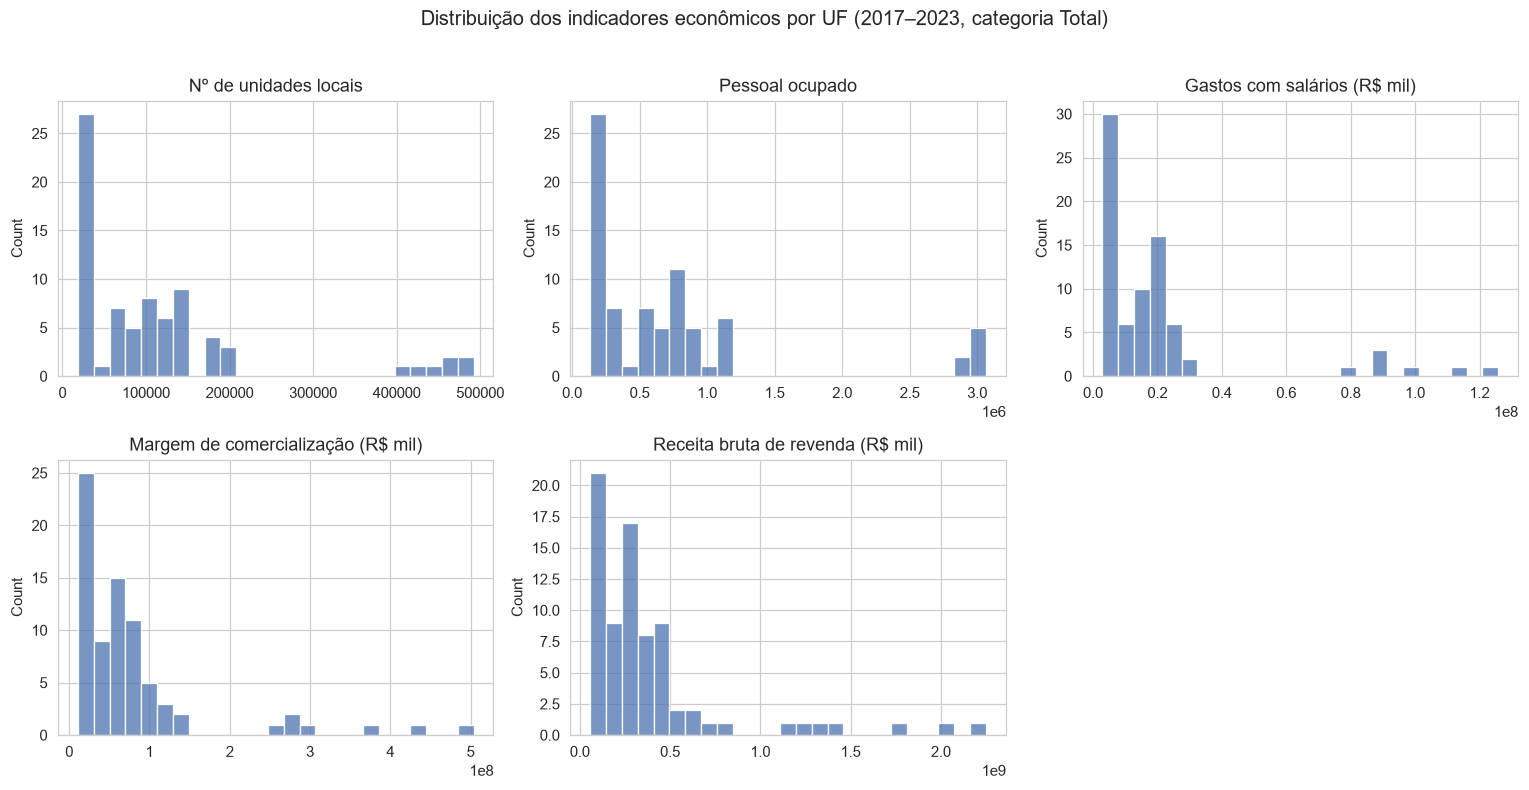

In [9]:
variaveis = ['unidades_locais', 'pessoal_ocupado', 'gastos_salarios', 'margem_comercializacao', 'receita_bruta']
titulos = ['Nº de unidades locais', 'Pessoal ocupado', 'Gastos com salários (R$ mil)',
           'Margem de comercialização (R$ mil)', 'Receita bruta de revenda (R$ mil)']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, var, titulo in zip(axes.flat, variaveis, titulos):
    sns.histplot(uf_total[var], bins=25, ax=ax, color="#4C72B0")
    ax.set_title(titulo)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
plt.suptitle("Distribuição dos indicadores econômicos por UF (2017–2023, categoria Total)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


As distribuições são fortemente assimétricas à direita — esperado, já que estados como São Paulo concentram uma quantidade de empresas, empregos e receita muito acima da média dos demais. Isso reforça que, na etapa de pré-processamento, provavelmente será necessário normalizar/padronizar essas variáveis antes de usá-las como atributos em algoritmos sensíveis à escala.

## 4. Boxplots por período (Pré-pandemia, Pandemia, Retomada)

Em vez de olhar os níveis absolutos (que variam demais entre UFs), vamos comparar a **variação percentual ano a ano** de cada indicador — essa é a métrica que efetivamente captura o impacto da pandemia e será a base da futura variável de desempenho (Passo 3 do roteiro).

C:\Users\LENOVO 059\AppData\Local\Temp\ipykernel_41604\2551150486.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uf_total, x='periodo', y=var + '_var%', ax=ax, palette="Set2")
C:\Users\LENOVO 059\AppData\Local\Temp\ipykernel_41604\2551150486.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uf_total, x='periodo', y=var + '_var%', ax=ax, palette="Set2")
C:\Users\LENOVO 059\AppData\Local\Temp\ipykernel_41604\2551150486.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uf_total, x='periodo', y=var + '_var%', ax=ax, palet

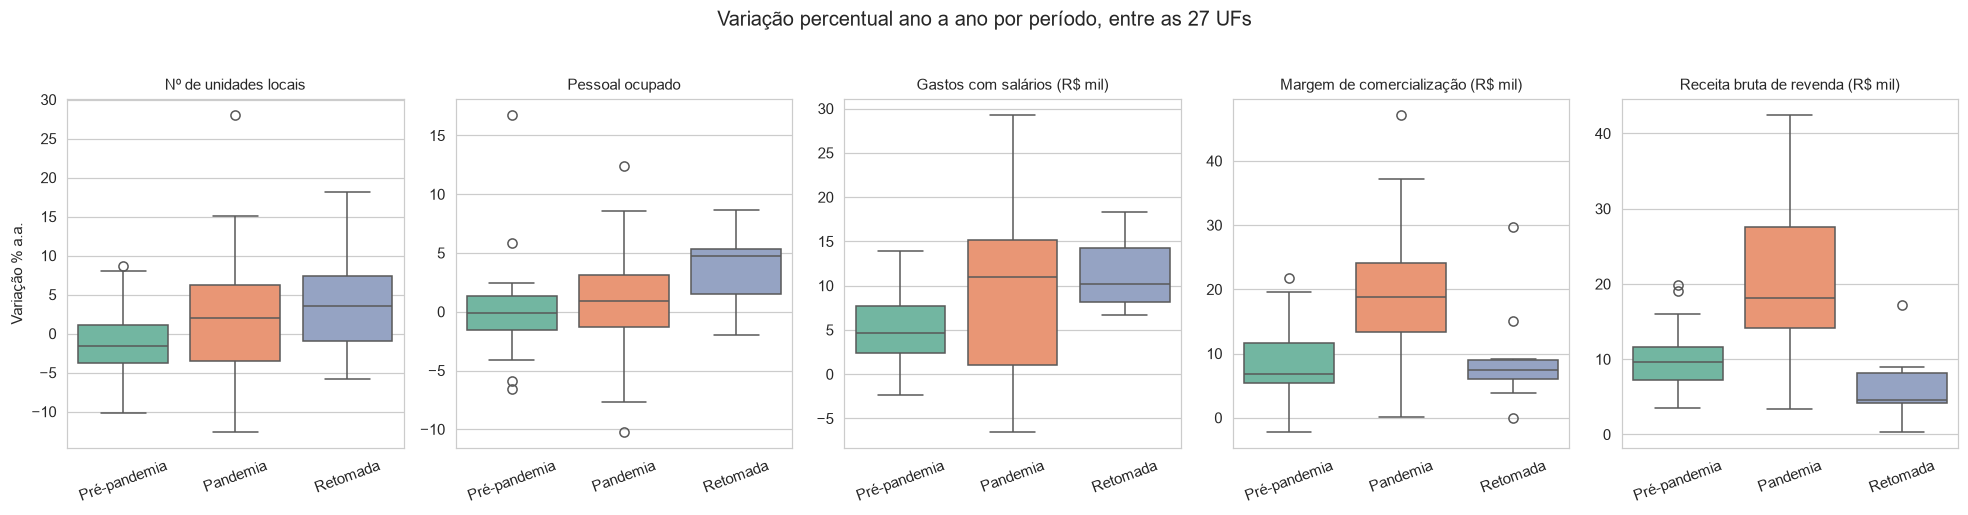

In [10]:
uf_total = uf_total.sort_values(['geografia', 'ano'])
for var in variaveis:
    uf_total[var + '_var%'] = uf_total.groupby('geografia')[var].pct_change() * 100

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5), sharex=True)
for ax, var, titulo in zip(axes, variaveis, titulos):
    sns.boxplot(data=uf_total, x='periodo', y=var + '_var%', ax=ax, palette="Set2")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Variação % a.a." if var == variaveis[0] else "")
    ax.tick_params(axis='x', rotation=20)
plt.suptitle("Variação percentual ano a ano por período, entre as 27 UFs", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


**Insight-chave:** a **receita bruta nominal** cresceu em praticamente todos os estados mesmo durante a pandemia (provavelmente reflexo da inflação e da migração para o comércio essencial/e-commerce). Já o **número de unidades locais** e o **pessoal ocupado** caem claramente em 2020 e só voltam a crescer com força a partir de 2021 — esses dois indicadores parecem ser sinais muito mais fiéis do impacto real da pandemia sobre o setor do que a receita nominal isoladamente. Isso é importante para a etapa de pré-processamento: a variável de desempenho (queda/estável/crescimento) talvez deva ser construída a partir de pessoal ocupado e/ou nº de unidades, não apenas da receita nominal.

## 5. Evolução temporal por macrorregião

Como cada uma das 5 variáveis evoluiu, ano a ano, por macrorregião — com destaque para o período de pandemia.

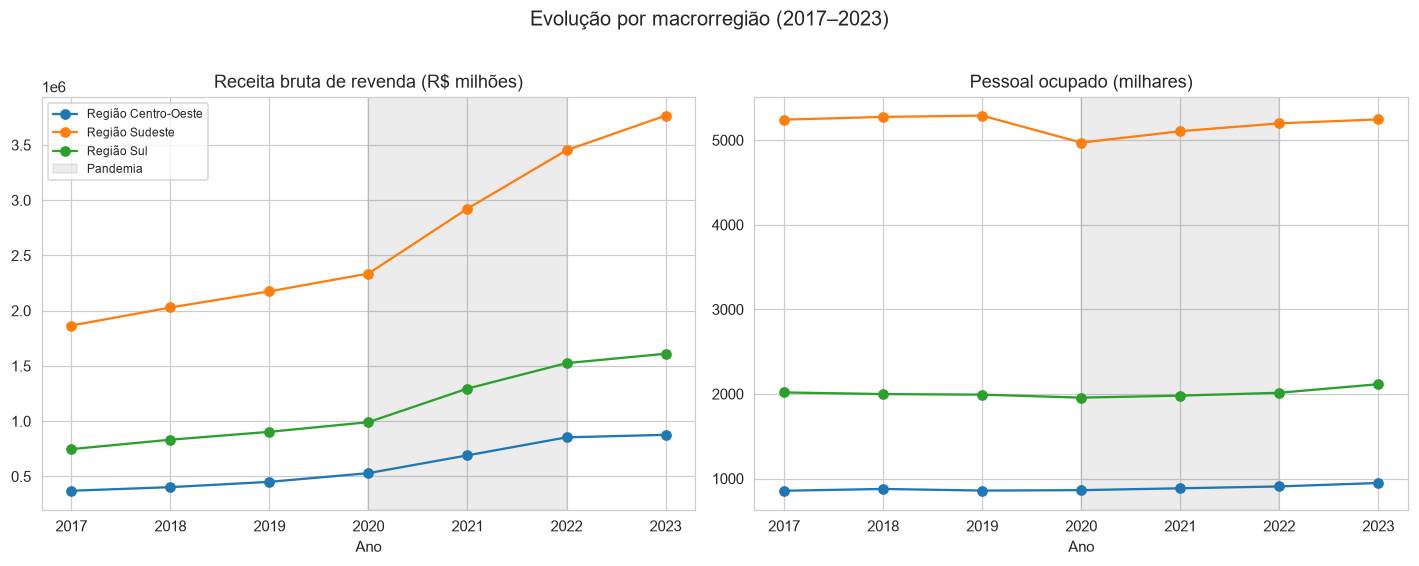

In [11]:
regiao_ano = (
    total_todos_niveis[total_todos_niveis['nivel_geografico'] == 'Região']
    .groupby(['geografia', 'ano'])[variaveis].sum().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for geo, grupo in regiao_ano.groupby('geografia'):
    axes[0].plot(grupo['ano'], grupo['receita_bruta'] / 1000, marker='o', label=geo)
    axes[1].plot(grupo['ano'], grupo['pessoal_ocupado'] / 1000, marker='o', label=geo)

for ax, titulo in zip(axes, ['Receita bruta de revenda (R$ milhões)', 'Pessoal ocupado (milhares)']):
    ax.axvspan(2020, 2022, color='grey', alpha=0.15, label='Pandemia')
    ax.set_title(titulo)
    ax.set_xlabel('Ano')

axes[0].legend(fontsize=8, loc='upper left')
plt.suptitle("Evolução por macrorregião (2017–2023)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


A região Sudeste domina em volume absoluto (esperado, dada sua participação no PIB nacional), mas o gráfico deixa visível a **desaceleração/leve queda do pessoal ocupado em 2020 em todas as regiões**, seguida de recuperação consistente a partir de 2021 — o mesmo padrão em formato de "V" aparece em todas elas, com intensidade um pouco diferente.

## 6. Matriz de correlação entre as variáveis

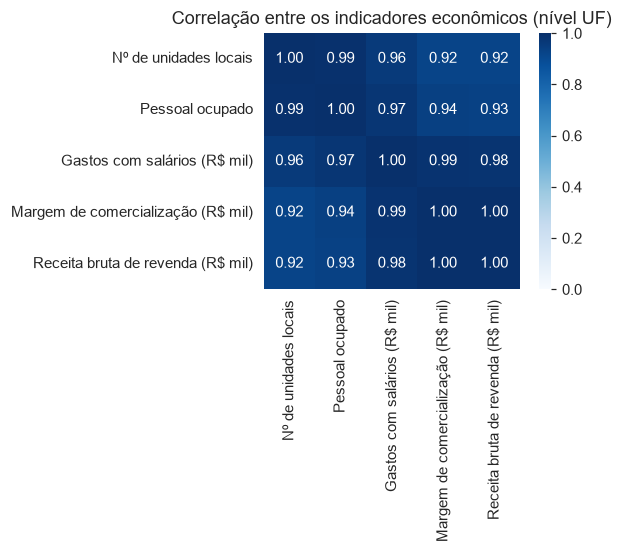

In [12]:
corr = uf_total[variaveis].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True,
            xticklabels=titulos, yticklabels=titulos)
plt.title("Correlação entre os indicadores econômicos (nível UF)")
plt.tight_layout()
plt.show()


Como esperado, todas as variáveis são **fortemente correlacionadas entre si** (todas medem, de formas diferentes, o tamanho da atividade comercial de um estado). Isso é um sinal de alerta para a etapa de pré-processamento: usar as 5 variáveis em nível absoluto como atributos de um modelo traria forte multicolinearidade — pode ser mais interessante trabalhar com as **variações percentuais** ou com **razões** (ex.: receita por unidade local, receita por funcionário) em vez dos níveis brutos, e avaliar se PCA/seleção de atributos se justifica.

## 7. Gráfico de dispersão: pessoal ocupado × receita bruta

Colorido por período, para visualizar se a relação entre as duas variáveis mudou durante a pandemia.

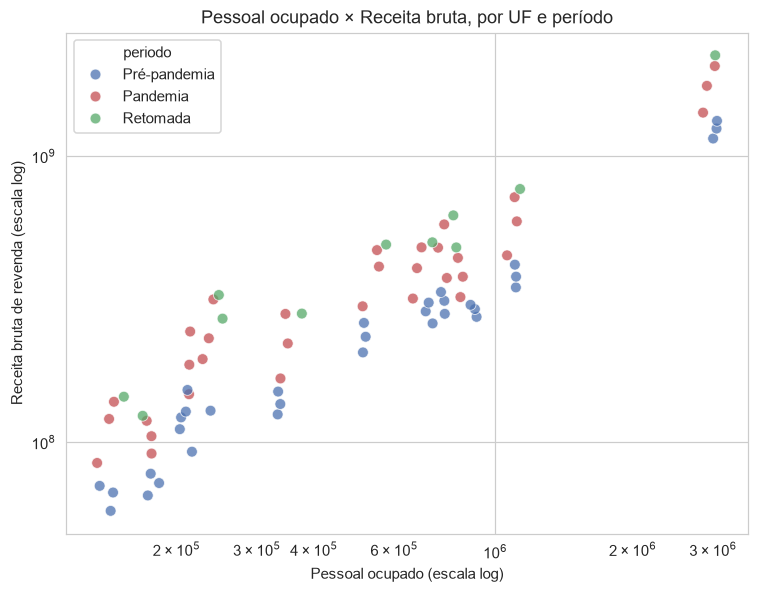

In [13]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(
    data=uf_total, x='pessoal_ocupado', y='receita_bruta',
    hue='periodo', palette={'Pré-pandemia': '#4C72B0', 'Pandemia': '#C44E52', 'Retomada': '#55A868'},
    alpha=0.75, s=50
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Pessoal ocupado (escala log)')
plt.ylabel('Receita bruta de revenda (escala log)')
plt.title('Pessoal ocupado × Receita bruta, por UF e período')
plt.tight_layout()
plt.show()


A relação entre pessoal ocupado e receita é aproximadamente linear em escala logarítmica (o que é esperado — estados maiores têm mais empregados *e* mais receita), e os pontos dos três períodos ficam bastante misturados, sem um deslocamento visual óbvio. Isso confirma que os efeitos da pandemia aparecem melhor na **variação ao longo do tempo por estado** (seção 4) do que na relação estática entre as variáveis.

## 8. Comparação por grupo de atividade (veículos, atacado, varejo)

Usando apenas o nível UF (o único com detalhamento por grande grupo de atividade — ver seção 2), comparamos como cada grande grupo de atividade se comportou.

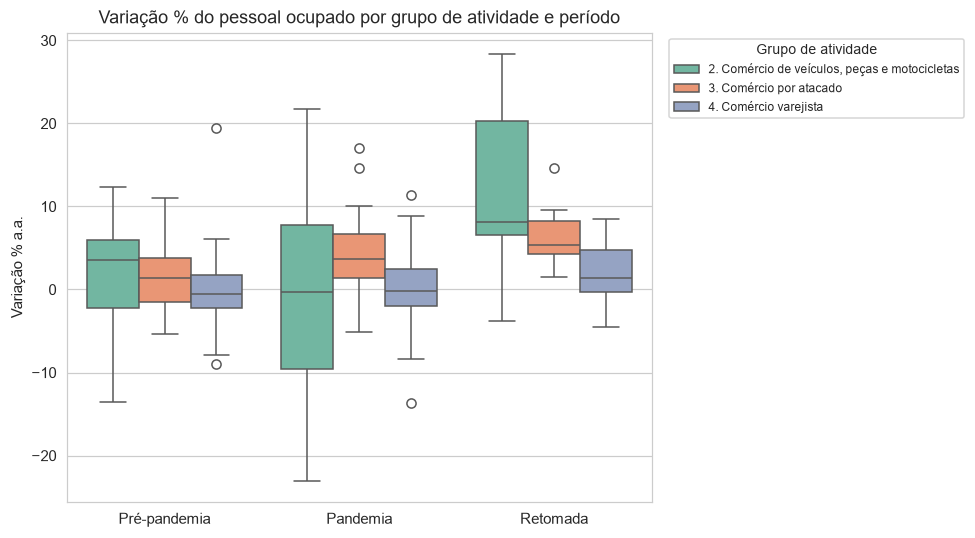

In [14]:
grupos_principais = ['2. Comércio de veículos, peças e motocicletas', '3. Comércio por atacado', '4. Comércio varejista']
uf_grupos = uf_categorias[uf_categorias['categoria'].isin(grupos_principais)].copy()
uf_grupos = uf_grupos.sort_values(['categoria', 'geografia', 'ano'])
uf_grupos['pessoal_var%'] = uf_grupos.groupby(['categoria', 'geografia'])['pessoal_ocupado'].pct_change() * 100

plt.figure(figsize=(9, 5))
sns.boxplot(data=uf_grupos, x='periodo', y='pessoal_var%', hue='categoria', palette="Set2")
plt.title('Variação % do pessoal ocupado por grupo de atividade e período')
plt.ylabel('Variação % a.a.')
plt.xlabel('')
plt.legend(title='Grupo de atividade', fontsize=8, title_fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Esse recorte por grupo de atividade é o mais interessante para a proposta: dá para comparar visualmente se **comércio de veículos** (mais sensível a bens duráveis e cadeias de suprimento) sofreu de forma diferente de **atacado** e **varejo** (que incluem itens essenciais) durante a pandemia — essa distinção deve aparecer com força na modelagem de classificação da Parte I em diante.

## 9. Ranking: UFs mais afetadas em 2020 e com maior recuperação em 2023

Usando o **pessoal ocupado** (indicador mais fiel ao impacto real, ver seção 4) como referência.

In [15]:
queda_2020 = (
    uf_total[uf_total['ano'] == 2020][['geografia', 'macrorregiao', 'pessoal_ocupado_var%']]
    .sort_values('pessoal_ocupado_var%')
    .rename(columns={'pessoal_ocupado_var%': 'variação % pessoal ocupado 2020'})
)
print("5 UFs com maior queda de pessoal ocupado em 2020:")
print(queda_2020.head(5).to_string(index=False))

crescimento_2023 = (
    uf_total[uf_total['ano'] == 2023][['geografia', 'macrorregiao', 'pessoal_ocupado_var%']]
    .sort_values('pessoal_ocupado_var%', ascending=False)
    .rename(columns={'pessoal_ocupado_var%': 'variação % pessoal ocupado 2023'})
)
print("\n5 UFs com maior crescimento de pessoal ocupado em 2023 (retomada):")
print(crescimento_2023.head(5).to_string(index=False))


5 UFs com maior queda de pessoal ocupado em 2020:
        geografia   macrorregiao  variação % pessoal ocupado 2020
   Espírito Santo Região Sudeste                       -10.274082
Rio Grande do Sul     Região Sul                        -7.667763
        São Paulo Região Sudeste                        -6.800275
   Rio de Janeiro Região Sudeste                        -4.978379
     Minas Gerais Região Sudeste                        -3.866403

5 UFs com maior crescimento de pessoal ocupado em 2023 (retomada):
         geografia        macrorregiao  variação % pessoal ocupado 2023
             Goiás Região Centro-Oeste                         8.629622
    Espírito Santo      Região Sudeste                         7.174789
 Rio Grande do Sul          Região Sul                         5.626181
Mato Grosso do Sul Região Centro-Oeste                         5.126660
    Santa Catarina          Região Sul                         4.720656


## 10. Passo 3 — Dados ausentes e tratamento

Primeiro item do pré-processamento. A aba *Notas* do arquivo define quatro símbolos: `-` (zero absoluto), `X` (valor inibido por sigilo), `..` (não se aplica) e `...` (não disponível). A função `limpar_valor` (seção 1) converte `X`, `..` e `...` em `NaN` e `-` em zero. Falta verificar quais desses símbolos aparecem de fato e o que os zeros representam — já considerando o recorte geográfico da seção 1.1.


In [16]:
# 10.1 Quais símbolos do SIDRA aparecem nas abas brutas? Sobrou algum NaN após a carga?
# (a contagem de símbolos abaixo é sobre o arquivo bruto completo, com as 33 geografias originais;
#  os demais números desta célula já usam `df`, ou seja, já refletem o recorte da seção 1.1)
xls = pd.ExcelFile(DATA_PATH)
contagem = {}
for aba in [s for s in xls.sheet_names if s != 'Notas']:
    raw = pd.read_excel(DATA_PATH, sheet_name=aba, header=None)
    col0 = raw[0].astype(str)
    fim = col0[col0.str.contains('Fonte', na=False)].index[0]
    celulas = raw.iloc[5:fim, 4:].values.ravel()
    textos = pd.Series([c.strip() for c in celulas if isinstance(c, str)])
    variavel = str(raw.iloc[1, 0]).replace('Variável - ', '').strip()
    contagem[NOMES_CURTOS[variavel]] = textos[textos.isin(['-', 'X', '..', '...'])].value_counts()

simbolos = pd.DataFrame(contagem).reindex(['-', 'X', '..', '...']).fillna(0).astype(int)
print("Ocorrências de cada símbolo nas abas brutas — arquivo completo, 33 geografias (por variável):")
display(simbolos)

print("NaN por coluna após a carga (já no recorte de 15 geografias):")
print(df[variaveis].isna().sum().to_string())
print(f"\nRegistros com receita_bruta = 0, já no recorte: {(df['receita_bruta'] == 0).sum()} de {len(df)} ({(df['receita_bruta'] == 0).mean():.0%})")


Ocorrências de cada símbolo nas abas brutas — arquivo completo, 33 geografias (por variável):


,unidades_locais,pessoal_ocupado,gastos_salarios,margem_comercializacao,receita_bruta
-,3717,3717,3717,3759,3717
X,0,0,0,0,0
..,0,0,0,0,0
...,0,0,0,0,0


NaN por coluna após a carga (já no recorte de 15 geografias):
unidades_locais           0
pessoal_ocupado           0
gastos_salarios           0
margem_comercializacao    0
receita_bruta             0

Registros com receita_bruta = 0, já no recorte: 1281 de 2415 (53%)


**Leitura:** só o símbolo `-` aparece no arquivo bruto (nenhum `X`, `..` ou `...`) e não sobra nenhum `NaN` após a carga. Formalmente, portanto, **não há dados ausentes**. Mas no recorte de 15 geografias (seção 1.1), **53% dos registros (1.281 de 2.415) são `-`** — um pouco menos que os 70% do arquivo bruto completo, já que parte dos registros zerados (os de Norte e Nordeste) foi removida no recorte geográfico. Pela legenda, `-` seria um "zero absoluto" (a atividade existe e o valor é realmente zero), o que ainda é implausível para mais da metade dos registros. A célula seguinte mostra onde eles estão.


In [17]:
# 10.2 Onde estão os zeros? Um registro é "sem dado" quando as 5 variáveis são 0 ao mesmo tempo.
GRUPOS_PRINCIPAIS = ['1. Total', '2. Comércio de veículos, peças e motocicletas',
                     '3. Comércio por atacado', '4. Comércio varejista']
sem_dado = (df[variaveis] == 0).all(axis=1)
eh_subgrupo = ~df['categoria'].isin(GRUPOS_PRINCIPAIS)

UFS_COM_DETALHE = sorted(df.loc[(df['nivel_geografico'] == 'UF') & eh_subgrupo & ~sem_dado, 'geografia'].unique())
print("UFs mantidas com dados nos subgrupos 3.x e 4.x:", UFS_COM_DETALHE, "\n")

ordem = ['Brasil/Região — Total', 'Brasil/Região — demais categorias', 'UF — Total e grupos 2, 3 e 4',
         'UF com detalhe (6) — subgrupos 3.x e 4.x', 'UF sem detalhe (5) — subgrupos 3.x e 4.x']
tipo = np.select(
    [(df['nivel_geografico'] != 'UF') & (df['categoria'] == '1. Total'),
     (df['nivel_geografico'] != 'UF'),
     ~eh_subgrupo,
     df['geografia'].isin(UFS_COM_DETALHE)],
    ordem[:4], default=ordem[4])

resumo = (pd.DataFrame({'tipo': pd.Categorical(tipo, categories=ordem, ordered=True), 'sem_dado': sem_dado})
          .groupby('tipo', observed=True)['sem_dado']
          .agg(registros='size', sem_dado='sum'))
resumo['% sem dado'] = (resumo['sem_dado'] / resumo['registros'] * 100).round(0).astype(int)
display(resumo)
print(f"Total: {sem_dado.sum()} de {len(df)} registros ({sem_dado.mean():.0%}) têm as 5 variáveis iguais a zero.\n")

exemplo = df[(df['geografia'] == 'Goiás') & (df['ano'] == 2019) & df['categoria'].isin(
    ['1. Total', '3. Comércio por atacado', '3.2 Comércio de matérias-primas agrícolas e animais vivos',
     '4. Comércio varejista', '4.1.1 Hiper/Supermercado'])]
print("Exemplo — Goiás, 2019 (o grupo existe, mas o subgrupo aparece zerado):")
display(exemplo[['categoria', 'unidades_locais', 'pessoal_ocupado', 'receita_bruta']].reset_index(drop=True))


UFs mantidas com dados nos subgrupos 3.x e 4.x: ['Minas Gerais', 'Paraná', 'Rio Grande do Sul', 'Rio de Janeiro', 'Santa Catarina', 'São Paulo'] 



,registros,sem_dado,% sem dado
tipo,,,
Brasil/Região — Total,28,0,0
Brasil/Região — demais categorias,616,616,100
"UF — Total e grupos 2, 3 e 4",308,0,0
UF com detalhe (6) — subgrupos 3.x e 4.x,798,0,0
UF sem detalhe (5) — subgrupos 3.x e 4.x,665,665,100


Total: 1281 de 2415 registros (53%) têm as 5 variáveis iguais a zero.

Exemplo — Goiás, 2019 (o grupo existe, mas o subgrupo aparece zerado):


,categoria,unidades_locais,pessoal_ocupado,receita_bruta
0,1. Total,65784.0,334501.0,150244051.0
1,3. Comércio por atacado,8911.0,59060.0,73135048.0
2,3.2 Comércio de matérias-primas agrícolas e an...,0.0,0.0,0.0
3,4. Comércio varejista,49481.0,237604.0,61905689.0
4,4.1.1 Hiper/Supermercado,0.0,0.0,0.0


**O que isso revela:** os zeros não são aleatórios, seguem a estrutura de publicação da tabela.

- Brasil e as 3 regiões mantidas: só o "1. Total" tem dados; todo o resto é zero.
- As 11 UFs mantidas: Total e grupos 2, 3 e 4 sempre preenchidos.
- Subgrupos 3.x e 4.x: preenchidos só em MG, PR, RJ, RS, SC e SP; nas outras 5 UFs mantidas (ES, DF, GO, MS, MT), 100% zero.

No exemplo de Goiás, o atacado tem operação real em 2019, mas todos os seus subgrupos aparecem como zero. São, portanto, **dados ausentes disfarçados de zero** (o detalhamento não foi publicado para essas UFs) e não zeros reais.

**Tratamento:** as opções eram (1) manter os zeros, o que distorceria médias, correlações e taxas de variação (divisão por zero); (2) imputar, o que inventaria uma informação que o IBGE não publicou; ou (3) **remover** esses registros. Como a ausência é **estrutural** e não aleatória, a remoção é a escolha correta e não perde informação: os totais e os grandes grupos de todas as UFs mantidas continuam na base.


In [18]:
# 10.3 Tratamento
# (a) Remove os registros estruturais sem dado.
df_limpo = df.loc[~sem_dado].copy()
df_limpo['codigo'] = df_limpo['categoria'].str.split().str[0].str.rstrip('.')   # chave curta da categoria, ex.: '3.5.1'

# (b) Ainda restam zeros em registros com dado?
print("Zeros que restam em registros com dado:")
print((df_limpo[variaveis] == 0).sum().to_string())
print("\nCategorias com margem = 0:")
print(df_limpo.loc[df_limpo['margem_comercializacao'] == 0, 'categoria'].value_counts().to_string())

# (c) Margem em 3.1: zero "não se aplica" -> NaN, sem imputar.
mask_31 = df_limpo['codigo'] == '3.1'
df_limpo.loc[mask_31, 'margem_comercializacao'] = np.nan

print(f"\nRegistros: {len(df)} -> {len(df_limpo)} (removidos {len(df) - len(df_limpo)})")
print("\nNaN após o tratamento:")
print(df_limpo[variaveis].isna().sum().to_string())
print("\nRegistros por nível geográfico em df_limpo:")
print(df_limpo['nivel_geografico'].value_counts().to_string())


Zeros que restam em registros com dado:
unidades_locais            0
pessoal_ocupado            0
gastos_salarios            0
margem_comercializacao    42
receita_bruta              0

Categorias com margem = 0:
categoria
3.1 Representantes e agentes do comércio (exceto de veículos e motocicletas)    42

Registros: 2415 -> 1134 (removidos 1281)

NaN após o tratamento:
unidades_locais            0
pessoal_ocupado            0
gastos_salarios            0
margem_comercializacao    42
receita_bruta              0

Registros por nível geográfico em df_limpo:
nivel_geografico
UF        1106
Região      21
Brasil       7


**Restam 42 zeros, todos na margem de comercialização da categoria 3.1** (representantes e agentes do comércio, nas 6 UFs com detalhe × 7 anos). Nessa atividade as demais variáveis têm valores normais, mas a margem é sempre zero. Como a margem é *receita líquida de revenda menos custo da mercadoria vendida* (aba *Notas*), é provável que ela simplesmente **não se aplique** a agentes que atuam por comissão. Decisão: converter para `NaN` e **não imputar** (qualquer valor seria inventado). Nas etapas seguintes, indicadores derivados da margem ficam indefinidos para a categoria 3.1.

| Situação | Registros | Decisão | Justificativa |
|---|---|---|---|
| Zeros estruturais (5 variáveis = 0): Brasil/Região (616) e as 5 UFs mantidas sem detalhe (665) | 1.281 | **Remover** | Não são zeros reais; imputar criaria dado que não existe. Nenhum total ou grupo principal é perdido. |
| Margem = 0 na categoria 3.1 | 42 | **Converter para `NaN`**, sem imputar | Margem provavelmente não se aplica a agentes/representantes. |
| Total de Brasil e das 3 regiões mantidas | 28 | **Manter apenas como contexto** | São agregados das UFs (soma exata, ver seção 11); usá-los junto com as UFs em um modelo duplicaria informação. |

A partir daqui, `df_limpo` (1.134 registros) é a base de referência do pré-processamento. As seções 3 a 9 continuam válidas, pois usaram apenas registros com dados (Total e 3 grandes grupos no nível UF, além do Total de regiões) — já dentro do recorte geográfico da seção 1.1.


## 11. Passo 3 — Ruídos (inconsistências nos dados)

Ruído aqui significa valores incorretos ou inconsistentes. Como os dados são estatísticas oficiais já agregadas, o teste mais forte é a **consistência interna**: as partes precisam somar o todo. Verificamos (1) valores negativos e duplicatas; (2) soma das UFs mantidas = região; (3) soma das subcategorias = categoria-mãe; (4) plausibilidade (margem não pode superar a receita). Como o recorte da seção 1.1 excluiu Norte e Nordeste por decisão do projeto, a soma das 3 regiões mantidas **não deve** mais fechar com o Brasil — isso é tratado à parte, como uma medida de cobertura, e não como um teste de erro.


In [19]:
# 11. Testes de consistência interna (em df_limpo)
chave = ['geografia', 'ano']
resultados = []

def dif_pct_max(soma, referencia):
    # maior diferença relativa (%) entre a soma dos componentes e o valor agregado, nas 5 variáveis
    referencia = referencia.loc[soma.index]
    return ((soma - referencia).abs() / referencia).max().max() * 100

# 1) sanidade
resultados.append(('Valores negativos nas 5 variáveis', len(df_limpo), f"{int((df_limpo[variaveis] < 0).sum().sum())} violações"))
resultados.append(('Registros duplicados (categoria × geografia × ano)', len(df_limpo),
                   f"{int(df_limpo.duplicated(['categoria', 'geografia', 'ano']).sum())} violações"))

# 2) aditividade geográfica (categoria Total) — só entre as UFs e regiões mantidas
tot = df_limpo[df_limpo['categoria'] == '1. Total']
soma_ufs = tot[tot['nivel_geografico'] == 'UF'].groupby(['macrorregiao', 'ano'])[variaveis].sum()
regioes = tot[tot['nivel_geografico'] == 'Região'].set_index(['macrorregiao', 'ano'])[variaveis]
resultados.append(('Soma das UFs mantidas = Região (Total)', len(soma_ufs), f"{dif_pct_max(soma_ufs, regioes):.4f}%"))

# 3) aditividade entre categorias (nível UF)
uf = df_limpo[df_limpo['nivel_geografico'] == 'UF']
codigos = uf['codigo'].unique()
def componentes(pai):
    return [c for c in codigos if '.' in c and c.rsplit('.', 1)[0] == pai]

hierarquia = {'1': ['2', '3', '4'], '3': componentes('3'), '4': componentes('4'),
              '3.5': componentes('3.5'), '4.1': componentes('4.1')}
for pai, filhos in hierarquia.items():
    soma = uf[uf['codigo'].isin(filhos)].groupby(chave)[variaveis].sum()
    ref = uf[uf['codigo'] == pai].set_index(chave)[variaveis]
    resultados.append((f"Categoria {pai} = soma de {', '.join(filhos)}", len(soma), f"{dif_pct_max(soma, ref):.4f}%"))

# 4) plausibilidade
com_margem = df_limpo['margem_comercializacao'].notna()
viol = int((df_limpo.loc[com_margem, 'margem_comercializacao'] > df_limpo.loc[com_margem, 'receita_bruta']).sum())
resultados.append(('Margem de comercialização ≤ receita bruta', int(com_margem.sum()), f"{viol} violações"))

display(pd.DataFrame(resultados, columns=['Teste', 'Comparações', 'Maior desvio']))

margem_pct = (df_limpo['margem_comercializacao'] / df_limpo['receita_bruta'] * 100).dropna()
print("Margem de comercialização como % da receita bruta:")
print(margem_pct.describe().round(1).to_string())

# 5) cobertura: quanto as 3 regiões mantidas representam do Brasil (nao e teste de erro, e informativo)
brasil = tot[tot['nivel_geografico'] == 'Brasil'].set_index('ano')[variaveis]
soma_regioes = regioes.groupby('ano')[variaveis].sum()
cobertura = (soma_regioes / brasil * 100)
print("\nCobertura das 3 regiões mantidas sobre o Brasil (%, categoria Total), por ano:")
print(cobertura.round(1).to_string())


,Teste,Comparações,Maior desvio
0,Valores negativos nas 5 variáveis,1134,0 violações
1,Registros duplicados (categoria × geografia × ...,1134,0 violações
2,Soma das UFs mantidas = Região (Total),21,0.0000%
3,"Categoria 1 = soma de 2, 3, 4",77,0.0000%
4,"Categoria 3 = soma de 3.1, 3.2, 3.3, 3.4, 3.5,...",42,0.0000%
5,"Categoria 4 = soma de 4.1, 4.2, 4.3, 4.4, 4.5,...",42,0.0000%
6,"Categoria 3.5 = soma de 3.5.1, 3.5.2",42,0.0000%
7,"Categoria 4.1 = soma de 4.1.1, 4.1.2",42,0.0000%
8,Margem de comercialização ≤ receita bruta,1092,0 violações


Margem de comercialização como % da receita bruta:
count    1092.0
mean       22.0
std         9.3
min         4.7
25%        16.2
50%        20.1
75%        26.1
max        62.8

Cobertura das 3 regiões mantidas sobre o Brasil (%, categoria Total), por ano:
      unidades_locais  pessoal_ocupado  gastos_salarios  margem_comercializacao  receita_bruta
ano                                                                                           
2017             79.5             79.6             83.4                    81.5           80.8
2018             79.3             79.8             83.6                    81.8           80.9
2019             80.2             80.0             84.1                    81.8           81.2
2020             80.0             79.8             84.2                    81.7           81.3
2021             78.8             79.2             83.6                    82.4           81.5
2022             79.4             79.0             83.4                    8

**Resultado:** todos os testes de erro passam com desvio zero. As somas hierárquicas dentro do recorte mantido (UFs → região; veículos + atacado + varejo = Total; subgrupos = grupo) fecham exatamente, não há valores negativos nem duplicatas, e a margem nunca supera a receita (mediana de cerca de 20% da receita, com máximo de 62,8%).

**Cobertura vs. Brasil (informativo, não é erro):** como esperado após excluir Norte e Nordeste, as 3 regiões mantidas somam **entre 78% e 84%** do Brasil (Total), dependendo do indicador e do ano — nunca 100%, porque essa é exatamente a parcela do país que decidimos deixar de fora. Isso não é ruído: é a consequência direta e esperada da decisão da seção 1.1, e serve como lembrete de que qualquer conclusão deste notebook vale para "Sudeste + Sul + Centro-Oeste", não para o Brasil inteiro.

**Conclusão:** não há ruído do tipo erro de digitação ou inconsistência entre níveis. A única sujeira encontrada foram os zeros estruturais da seção 10. Uma ressalva: testes de consistência não detectam **erro amostral**. A PAC é uma pesquisa por amostragem, então oscilações pontuais em UFs pequenas podem existir sem violar nenhuma soma. Isso ajuda a interpretar alguns valores extremos da próxima seção.


## 12. Passo 3 — Outliers

Valor extremo não é o mesmo que erro. Como a seção 11 não achou ruído, a pergunta aqui é se os extremos são **legítimos**. Cada indicador pode ser olhado em três escalas, que tratamos separadamente com o critério do IQR (fora de 1,5 × IQR) e, nas razões, com z-score modificado (mediana/MAD):

1. **Nível** (valor absoluto por UF, categoria Total);
2. **Variação % anual** (a base da futura variável de desempenho);
3. **Razões dentro da categoria** (receita por pessoa, salário médio, pessoal por unidade, margem %), que neutralizam o tamanho do estado.


### 12.1 Outliers no nível dos indicadores (11 UFs × 7 anos, categoria Total)

,Indicador,Outliers (de 77),UFs (nº de anos),Assimetria (nível),Assimetria (log10)
0,Nº de unidades locais,7,São Paulo (7),2.02,0.22
1,Pessoal ocupado,7,São Paulo (7),2.15,0.41
2,Gastos com salários (R$ mil),7,São Paulo (7),2.63,0.53
3,Margem de comercialização (R$ mil),7,São Paulo (7),2.80,0.46
4,Receita bruta de revenda (R$ mil),7,São Paulo (7),2.66,0.40


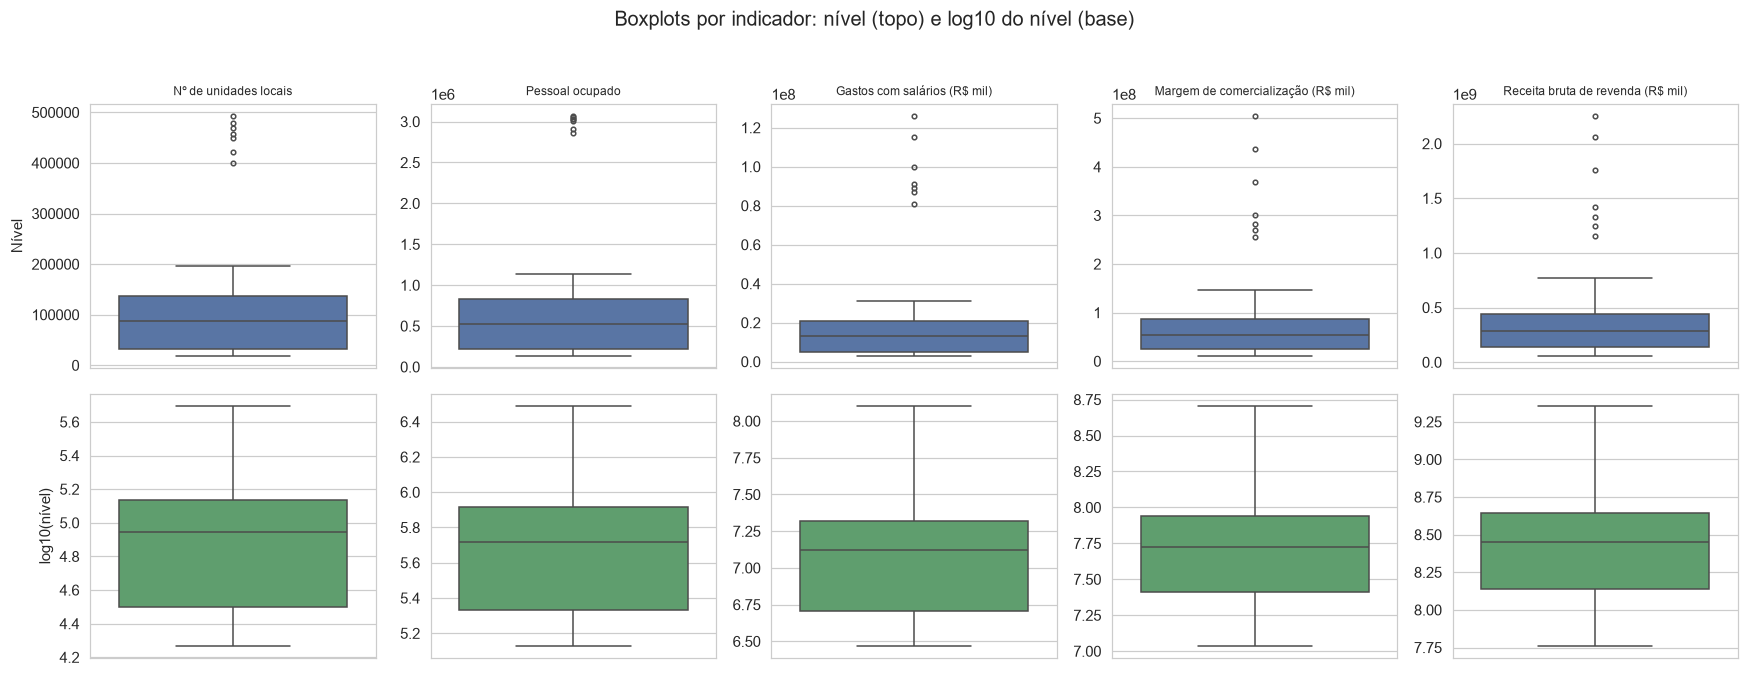

In [20]:
def mascara_iqr(serie, k=1.5):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - k * iqr) | (serie > q3 + k * iqr)

tab = []
for var, titulo in zip(variaveis, titulos):
    m = mascara_iqr(uf_total[var])
    por_uf = uf_total.loc[m, 'geografia'].value_counts()
    tab.append({'Indicador': titulo, 'Outliers (de 77)': int(m.sum()),
                'UFs (nº de anos)': ', '.join(f"{uf} ({n})" for uf, n in por_uf.items()),
                'Assimetria (nível)': round(uf_total[var].skew(), 2),
                'Assimetria (log10)': round(np.log10(uf_total[var]).skew(), 2)})
display(pd.DataFrame(tab))

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for j, (var, titulo) in enumerate(zip(variaveis, titulos)):
    sns.boxplot(y=uf_total[var], ax=axes[0, j], color="#4C72B0", fliersize=3)
    axes[0, j].set_title(titulo, fontsize=8)
    axes[0, j].set_ylabel("Nível" if j == 0 else "")
    sns.boxplot(y=np.log10(uf_total[var]), ax=axes[1, j], color="#55A868", fliersize=3)
    axes[1, j].set_ylabel("log10(nível)" if j == 0 else "")
plt.suptitle("Boxplots por indicador: nível (topo) e log10 do nível (base)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


**Leitura:** com o recorte de 11 UFs (todas de regiões mais desenvolvidas), os outliers de nível ficam concentrados em um único estado: **São Paulo aparece nos 7 anos, nas 5 variáveis**. Minas Gerais, que aparecia como outlier na análise com as 27 UFs, deixou de ser um valor extremo — dentro deste grupo mais homogêneo de 11 UFs, o porte de MG não se destaca tanto. Isso não é erro, é o maior mercado do país. Remover esse registro descartaria justamente o caso mais relevante.

O problema real continua sendo a **assimetria**: ela fica entre 2,0 e 2,8 nos níveis (menor que os 3,1–4,2 da base completa, já que tirar Norte/Nordeste reduz a heterogeneidade) e cai para valores entre 0,2 e 0,5 com `log10` (linha de baixo do gráfico, onde o ponto isolado de SP praticamente desaparece). **Decisão: manter o registro e tratar a escala** (transformação log10 ou padronização robusta) quando os níveis forem usados como atributos.


### 12.2 Outliers nas variações percentuais anuais (base da variável de desempenho)


In [21]:
tab, achados = [], []
for var, titulo in zip(variaveis, titulos):
    s = uf_total[var + '_var%'].dropna()
    m = mascara_iqr(s)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    tab.append({'Indicador': titulo, 'Observações': len(s), 'Outliers': int(m.sum()),
                'Limites IQR (%)': f"[{q1 - 1.5 * iqr:.1f} ; {q3 + 1.5 * iqr:.1f}]",
                'Mín. (%)': round(s.min(), 1), 'Máx. (%)': round(s.max(), 1)})
    for i in s[m].index:
        achados.append({'Indicador': titulo, 'UF': uf_total.loc[i, 'geografia'],
                        'Ano': int(uf_total.loc[i, 'ano']), 'Variação %': round(s[i], 1)})

display(pd.DataFrame(tab))
print("Observações identificadas como outliers:")
display(pd.DataFrame(achados))


,Indicador,Observações,Outliers,Limites IQR (%),Mín. (%),Máx. (%)
0,Nº de unidades locais,66,2,[-17.0 ; 18.2],-12.7,28.1
1,Pessoal ocupado,66,4,[-7.6 ; 9.5],-10.3,16.8
2,Gastos com salários (R$ mil),66,0,[-13.3 ; 29.6],-6.6,29.3
3,Margem de comercialização (R$ mil),66,1,[-13.6 ; 39.4],-2.3,47.2
4,Receita bruta de revenda (R$ mil),66,2,[-9.8 ; 36.0],0.3,42.5


Observações identificadas como outliers:


,Indicador,UF,Ano,Variação %
0,Nº de unidades locais,Mato Grosso do Sul,2021,28.1
1,Nº de unidades locais,Rio de Janeiro,2023,18.2
2,Pessoal ocupado,Espírito Santo,2019,16.8
3,Pessoal ocupado,Espírito Santo,2020,-10.3
4,Pessoal ocupado,Mato Grosso,2022,12.4
5,Pessoal ocupado,Rio Grande do Sul,2020,-7.7
6,Margem de comercialização (R$ mil),Mato Grosso do Sul,2021,47.2
7,Receita bruta de revenda (R$ mil),Mato Grosso do Sul,2021,42.5
8,Receita bruta de revenda (R$ mil),Santa Catarina,2021,37.7


**Leitura:** só **9 observações** (de 330) são outliers de variação, cerca de 2,7%. Não são mais só altas: aparecem também quedas. Os destaques:

- **Mato Grosso do Sul, 2021:** salta em três indicadores ao mesmo tempo — unidades locais (+28,1%), margem (+47,2%) e receita (+42,5%) — provavelmente reabertura da economia somada à inflação de 2021 (valores nominais).
- **Espírito Santo:** pessoal ocupado sobe 16,8% em 2019 e cai 10,3% logo em 2020 — o mesmo padrão já observado antes, e que agora aparece como outlier estatístico nos dois anos dentro deste grupo mais homogêneo de 11 UFs. É o caso que mais pede cautela: pode ser oscilação amostral, e não só efeito da pandemia.
- **Rio Grande do Sul, 2020:** -7,7% de pessoal ocupado, a queda mais discreta da lista, mas ainda fora do padrão das outras 10 UFs mantidas.
- **Mato Grosso, 2022** (+12,4%) e **Santa Catarina, 2021** (+37,7% de receita) e **Rio de Janeiro, 2023** (+18,2% de unidades locais) completam a lista, todos como crescimento pontual.

**Decisão:** manter todas as observações, sem transformação — nenhum valor é implausível, e o caso do Espírito Santo já havia sido sinalizado na seção 4. Vale ter atenção redobrada a ele ao interpretar o modelo.


### 12.3 Outliers nas razões, dentro de cada categoria de atividade

Comparar razões de atividades diferentes não faz sentido, porque a receita por pessoa de combustíveis é estruturalmente maior do que a de um varejo de vestuário. O gráfico abaixo mostra isso (a mediana vai de cerca de R$ 80 mil por pessoa em artigos usados, 4.7, a cerca de R$ 10 milhões em combustíveis, 3.5.1), e por isso o z-score modificado é calculado **dentro de cada categoria** (23 categorias, usando todas as UFs e anos com dado).


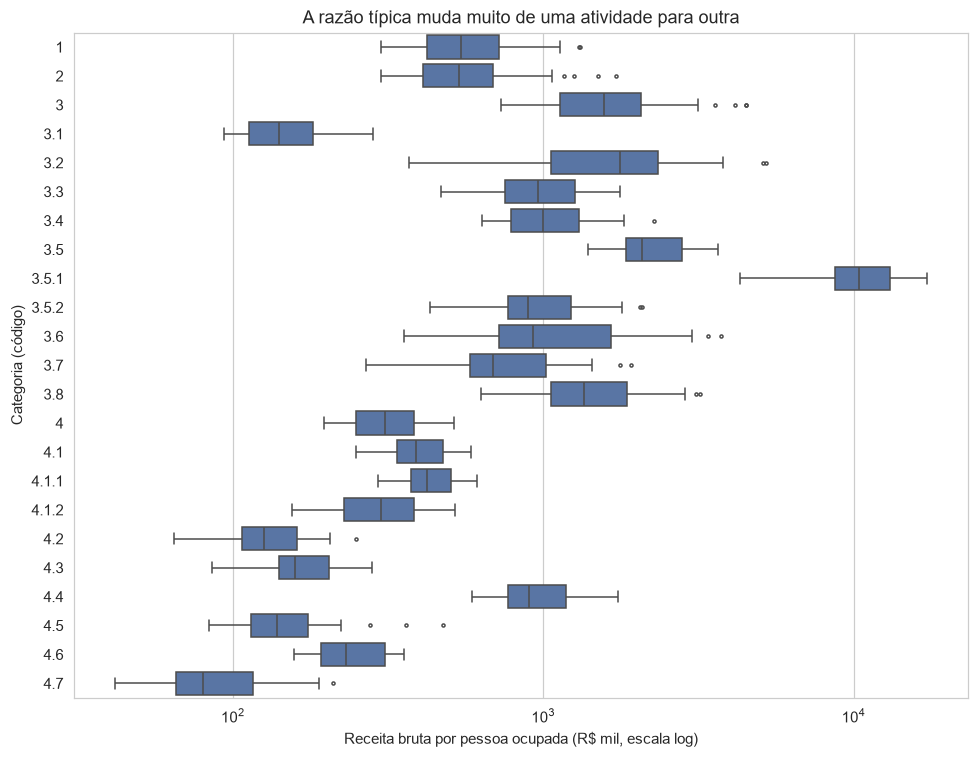

,Razão,Outliers IQR global,"Outliers intra-categoria (|z| > 3,5)"
0,receita_por_pessoa,86,20
1,salario_medio,59,15
2,pessoal_por_unidade,88,35
3,margem_pct,32,14


Registros com ao menos uma razão atípica dentro da própria categoria: 73 de 1106 (6.6%)

Por UF (5 maiores):
geografia
Rio de Janeiro    38
São Paulo         10
Santa Catarina     9
Mato Grosso        5
Minas Gerais       3

Por ano:
ano
2017     8
2018     9
2019     9
2020     8
2021     8
2022    13
2023    18

Pares UF × categoria com algum ano atípico: 28
Nº de anos (de 7) em que o par foi atípico -> nº de pares:
outlier_razao
1    8
2    8
3    7
4    1
5    2
7    2

Pares atípicos em 4 ou mais anos:
geografia       categoria                                                                        
Rio de Janeiro  3.5.1 Combustíveis e lubrificantes                                                   7
                4.1.1 Hiper/Supermercado                                                             7
                4.1.2 Outros tipos de comércio não-especializado                                     5
                4.4 Combustíveis e lubrificantes                                

,categoria,geografia,ano,receita_por_pessoa,salario_medio,pessoal_por_unidade,margem_pct,z_max
0,3.5.1 Combustíveis e lubrificantes,Rio de Janeiro,2018,5164.04,138.98,34.75,7.15,9.91
1,3.5.1 Combustíveis e lubrificantes,Rio de Janeiro,2022,8493.97,109.51,38.54,5.98,9.48
2,3.5.1 Combustíveis e lubrificantes,Rio de Janeiro,2021,6008.66,98.47,37.12,6.67,8.99
3,3.5.1 Combustíveis e lubrificantes,Rio de Janeiro,2019,6026.19,129.40,30.32,6.67,8.76
4,3.5.1 Combustíveis e lubrificantes,Rio de Janeiro,2023,9086.64,129.14,32.97,6.09,8.73
5,3.5.1 Combustíveis e lubrificantes,Rio de Janeiro,2017,4314.72,125.55,34.76,6.96,8.30
6,4.1.1 Hiper/Supermercado,Rio de Janeiro,2020,443.84,23.38,112.27,20.46,8.24
7,4.1.1 Hiper/Supermercado,Rio de Janeiro,2019,394.78,22.67,108.10,21.25,7.68
8,4.5 Equipamentos de informática e comunicação,Santa Catarina,2023,474.02,29.03,3.39,23.31,7.40
9,4.1.1 Hiper/Supermercado,Rio de Janeiro,2021,457.89,24.68,105.76,20.67,7.37


In [22]:
uf_razoes = df_limpo[df_limpo['nivel_geografico'] == 'UF'].copy()
uf_razoes['receita_por_pessoa'] = uf_razoes['receita_bruta'] / uf_razoes['pessoal_ocupado']          # R$ mil por pessoa
uf_razoes['salario_medio'] = uf_razoes['gastos_salarios'] / uf_razoes['pessoal_ocupado']            # R$ mil por pessoa/ano
uf_razoes['pessoal_por_unidade'] = uf_razoes['pessoal_ocupado'] / uf_razoes['unidades_locais']
uf_razoes['margem_pct'] = uf_razoes['margem_comercializacao'] / uf_razoes['receita_bruta'] * 100
razoes = ['receita_por_pessoa', 'salario_medio', 'pessoal_por_unidade', 'margem_pct']

def z_modificado(s):
    mediana = s.median()
    return 0.6745 * (s - mediana) / (s - mediana).abs().median()

for r in razoes:
    uf_razoes[r + '_z'] = uf_razoes.groupby('categoria')[r].transform(z_modificado)
uf_razoes['outlier_razao'] = uf_razoes[[r + '_z' for r in razoes]].abs().gt(3.5).any(axis=1)
uf_razoes['z_max'] = uf_razoes[[r + '_z' for r in razoes]].abs().max(axis=1)

ordem_cod = sorted(uf_razoes['codigo'].unique(), key=lambda c: [int(x) for x in c.split('.')])
plt.figure(figsize=(9, 7))
sns.boxplot(data=uf_razoes, x='receita_por_pessoa', y='codigo', order=ordem_cod, orient='h', color="#4C72B0", fliersize=2)
plt.xscale('log')
plt.xlabel('Receita bruta por pessoa ocupada (R$ mil, escala log)')
plt.ylabel('Categoria (código)')
plt.title('A razão típica muda muito de uma atividade para outra')
plt.tight_layout()
plt.show()

comp = []
for r in razoes:
    s = uf_razoes[r].dropna()
    comp.append({'Razão': r, 'Outliers IQR global': int(mascara_iqr(s).sum()),
                 'Outliers intra-categoria (|z| > 3,5)': int((uf_razoes[r + '_z'].abs() > 3.5).sum())})
display(pd.DataFrame(comp))

n_flag = int(uf_razoes['outlier_razao'].sum())
print(f"Registros com ao menos uma razão atípica dentro da própria categoria: {n_flag} de {len(uf_razoes)} ({n_flag / len(uf_razoes):.1%})")
print("\nPor UF (5 maiores):")
print(uf_razoes.loc[uf_razoes['outlier_razao']].groupby('geografia').size().sort_values(ascending=False).head(5).to_string())
print("\nPor ano:")
print(uf_razoes.groupby('ano')['outlier_razao'].sum().to_string())

persistencia = uf_razoes.groupby(['geografia', 'categoria'])['outlier_razao'].sum()
persistencia = persistencia[persistencia > 0]
print(f"\nPares UF × categoria com algum ano atípico: {len(persistencia)}")
print("Nº de anos (de 7) em que o par foi atípico -> nº de pares:")
print(persistencia.value_counts().sort_index().to_string())
print("\nPares atípicos em 4 ou mais anos:")
print(persistencia[persistencia >= 4].to_string())

print("\n10 registros mais extremos:")
display(uf_razoes.sort_values('z_max', ascending=False).head(10)[['categoria', 'geografia', 'ano'] + razoes + ['z_max']].round(2).reset_index(drop=True))


**Leitura:**

- Com o IQR global, entre 3% e 8% dos registros aparecem como outliers em cada razão, mas boa parte é **efeito da categoria** (combustíveis, hipermercados etc.). Medindo dentro da categoria, a proporção fica bem menor. No total, **73 de 1.106 registros (6,6%)** têm ao menos uma razão atípica — praticamente igual à proporção encontrada com as 27 UFs (6,9%), o que já era esperado: os casos mais extremos vinham do **Rio de Janeiro** (38 dos 73), que não foi afetado por este recorte.
- Os dois casos mais fortes continuam sendo do RJ: **combustíveis e lubrificantes (3.5.1)**, com receita por pessoa de R$ 4 a 9 milhões e salário médio bem acima do normal, e **hiper/supermercados (4.1.1)**, com cerca de 100 a 112 pessoas por unidade. Ambos são atípicos nos 7 anos, o que indica característica estrutural da atividade no RJ e não erro.
- Fora o RJ, os outliers agora aparecem em **São Paulo (10)**, **Santa Catarina (9)** e **Mato Grosso (5)** — sem os casos de Pará e Tocantins que apareciam antes (removidos junto com o Norte). O número de atípicos por ano continua crescendo (de 8 em 2017 para 18 em 2023), efeito provável da inflação sobre razões nominais.

**Decisão:** manter os registros e **sinalizá-los** (coluna `outlier_razao` de `uf_razoes`). Na modelagem, preferir escalas robustas (`RobustScaler`) ou winsorização, e testar a sensibilidade removendo os casos do RJ.


### 12.4 Resumo das decisões sobre outliers

| Escala | O que foi encontrado | Decisão |
|---|---|---|
| **Nível** (Total por UF) | 7 outliers em cada um dos 5 indicadores, todos de São Paulo | **Manter** (maior mercado do país, legítimo). Corrigir a assimetria com `log10` (de 2,0–2,8 para 0,2–0,5). |
| **Variação % anual** | 9 de 330 observações (2,7%); inclui altas (MS, MT, SC, RJ) e quedas (ES, RS) | **Manter**, sem transformação. Atenção redobrada ao caso do ES (2019–2020). |
| **Razões por categoria** | 73 de 1.106 registros (6,6%), concentrados no RJ (combustíveis e hipermercados) | **Manter e sinalizar** (`outlier_razao`). Usar escala robusta e testar a sensibilidade. |

**Nenhum registro foi removido nesta etapa.** Não há evidência de erro nos valores extremos (seção 11); eles descrevem a realidade heterogênea do comércio nas regiões mantidas, e removê-los enviesaria justamente a comparação entre estados e atividades.


## 13. Principais insights e próximos passos

- **Escopo geográfico:** por decisão do projeto (seção 1.1), Norte e Nordeste (16 UFs) foram excluídos. A análise cobre Sudeste, Sul e Centro-Oeste (11 UFs), que representam entre 78% e 84% do Brasil (Total) — nunca 100%, o que é o resultado esperado dessa exclusão (seção 11). Vale lembrar que a limitação de dados ausentes por subgrupo de atividade **não é exclusiva** de Norte/Nordeste: Centro-Oeste (4 UFs) e Espírito Santo continuam sem esse detalhamento mesmo após o recorte.
- **Cobertura dos dados:** Brasil e as 3 regiões mantidas só têm a categoria "1. Total"; nas 11 UFs, o Total e os 3 grandes grupos (veículos, atacado, varejo) estão completos, mas os 19 subgrupos 3.x e 4.x só têm dados em 6 UFs (MG, PR, RJ, RS, SC e SP). Os 1.281 registros restantes (53% da base recortada) eram zeros estruturais e foram removidos (seção 10), o que gerou `df_limpo` com 1.134 registros.
- **Consistência interna:** todos os testes de erro passaram com desvio zero (seção 11): UFs mantidas somam a região, veículos + atacado + varejo = Total e os subgrupos somam seus grupos. Não há ruído do tipo erro de digitação ou inconsistência entre níveis.
- **Outliers legítimos:** existem em três escalas (nível, variação % e razões), mas nenhum foi removido (seção 12). Com o recorte, os outliers de nível se concentram só em São Paulo (Minas Gerais deixou de ser extremo dentro deste grupo mais homogêneo); o padrão de outliers em razões (concentrado no Rio de Janeiro) não mudou.
- **Receita nominal x impacto real:** a receita bruta de revenda cresceu, em termos nominais, em quase todos os estados mesmo em 2020, provavelmente por efeito de inflação e de setores essenciais. Já **pessoal ocupado** e **número de unidades locais** mostram queda real e clara em 2020, com recuperação a partir de 2021, e parecem mais adequados para basear a futura variável de desempenho. Com o recorte, o **Espírito Santo** se destaca como o caso mais extremo (maior queda de pessoal ocupado em 2020 e maior salto em 2019), o que pede cautela na interpretação.
- **Multicolinearidade:** as 5 variáveis são fortemente correlacionadas entre si. Vale considerar razões (receita por unidade, receita por funcionário) ou as variações percentuais como atributos, em vez dos níveis absolutos.
- **Heterogeneidade regional:** as 3 macrorregiões mantidas seguem o mesmo padrão em "V" (queda em 2020, recuperação a partir de 2021), com intensidades diferentes, o que abre espaço para comparar a resiliência regional na modelagem.
- **Próximos passos:**
  - continuar com os demais itens do Passo 3 do roteiro, que vêm depois de *ruídos e outliers*;
  - definir formalmente a variável de desempenho (queda / estável / crescimento) e avaliar o balanceamento das classes (2020 deve concentrar as quedas);
  - escolher o nível de análise para evitar dupla contagem (Total = 2 + 3 + 4; grupo 3 = soma dos 3.x). Uma opção é usar as 11 UFs × 3 grandes grupos (231 registros) e analisar à parte as 6 UFs com detalhe;
  - considerar deflacionar os valores monetários (por exemplo, pelo IPCA), já que a comparação entre anos hoje é nominal.
